In [6]:
import sys, os
sys.path.append('../1_data_extraction')

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import cv2

from sklearn.model_selection import train_test_split

from LRO_data_class import DEM_PPD, getRegionalLunarData, getDEMLunarData, getFilteredLabels, percentileNormalise, maskGeneration

PATCHES_DIR = './lunar_patches_alltiles'
FILTERED_LABELS_PATH = '../2_data_preparation/filtered_labels_alltiles.csv'


In [2]:
dataDEM_full = getDEMLunarData()
filteredLabels_all = getFilteredLabels(FILTERED_LABELS_PATH)

In [3]:
filteredLabels_all.head()

,CRATER_ID,LAT_CIRC_IMG,LON_CIRC_IMG,LAT_ELLI_IMG,LON_ELLI_IMG,DIAM_CIRC_IMG,DIAM_CIRC_SD_IMG,DIAM_ELLI_MAJOR_IMG,DIAM_ELLI_MINOR_IMG,DIAM_ELLI_ECCEN_IMG,...,DIAM_ELLI_ANGLE_IMG,LAT_ELLI_SD_IMG,LON_ELLI_SD_IMG,DIAM_ELLI_MAJOR_SD_IMG,DIAM_ELLI_MINOR_SD_IMG,DIAM_ELLI_ANGLE_SD_IMG,DIAM_ELLI_ECCEN_SD_IMG,DIAM_ELLI_ELLIP_SD_IMG,ARC_IMG,PTS_RIM_IMG
0,01-1-189500,59.9946,280.621,59.9948,280.620,3.42442,0.196357,4.02750,2.93063,0.685943,...,163.6420,0.000482,0.001284,0.048535,0.035195,1.709870,0.013133,0.023381,1.000000,30
1,01-1-189505,59.9999,271.943,60.0005,271.943,2.78498,0.243717,3.63427,1.95195,0.843521,...,109.2900,0.000925,0.000785,0.052269,0.032345,1.437670,0.007504,0.040852,0.750938,16
2,01-1-189527,59.9999,162.496,59.9999,162.496,1.76788,0.020729,1.79156,1.73944,0.239466,...,78.2722,0.000297,0.000611,0.020463,0.022637,20.555300,0.068162,0.017834,0.810232,11
3,01-1-189539,59.9971,123.437,60.0011,123.452,3.33136,0.098881,3.52154,2.56769,0.684365,...,118.2220,0.000456,0.001212,0.031186,0.051761,1.447160,0.017104,0.030197,0.680784,14
4,02-1-000038,55.3643,225.590,55.3647,225.590,7.25753,0.198344,7.89622,6.62395,0.544323,...,21.7880,0.000124,0.000247,0.010471,0.009234,0.357849,0.002487,0.002293,1.000000,126


In [4]:
TILES = [
    {'name': 'WAC_GLOBAL_E300N0450_100M', 'lat_min':   0, 'lat_max':  60, 'lon_min':   0, 'lon_max':  90},
    {'name': 'WAC_GLOBAL_E300N1350_100M', 'lat_min':   0, 'lat_max':  60, 'lon_min':  90, 'lon_max': 180},
    {'name': 'WAC_GLOBAL_E300N2250_100M', 'lat_min':   0, 'lat_max':  60, 'lon_min': 180, 'lon_max': 270},
    {'name': 'WAC_GLOBAL_E300N3150_100M', 'lat_min':   0, 'lat_max':  60, 'lon_min': 270, 'lon_max': 360},
    {'name': 'WAC_GLOBAL_E300S0450_100M', 'lat_min': -60, 'lat_max':   0, 'lon_min':   0, 'lon_max':  90},
    {'name': 'WAC_GLOBAL_E300S1350_100M', 'lat_min': -60, 'lat_max':   0, 'lon_min':  90, 'lon_max': 180},
    {'name': 'WAC_GLOBAL_E300S2250_100M', 'lat_min': -60, 'lat_max':   0, 'lon_min': 180, 'lon_max': 270},
    {'name': 'WAC_GLOBAL_E300S3150_100M', 'lat_min': -60, 'lat_max':   0, 'lon_min': 270, 'lon_max': 360},
]


## Patch extraction 

In [7]:
# [source]:  Silburt et al. (2019) - code

stored_indices = []
patch_lons = []
patch_lats = []
center_cols = []
center_rows = []

wac_batch = []
dem_batch = []
mask_batch = []

kept_parts = []

batch_num = 0
batch_size = 1000

os.makedirs(PATCHES_DIR, exist_ok=True)

np.random.seed(42)

for tile in TILES:
    print(f"\n--- {tile['name']} ---")

    lat_span = tile['lat_max'] - tile['lat_min']
    lon_span = tile['lon_max'] - tile['lon_min']

    dataWAC = getRegionalLunarData(tile['name'])

    # NB: the 128s here are the DEM's pixels PER DEGREE (DEM_PPD) - they index the
    # global product by latitude/longitude. The other 128s in this cell are half the
    # 256 px patch width and must NOT be changed with them; the two are equal only by
    # coincidence at 128 ppd. A blanket find-and-replace corrupts every patch silently.
    dataDEM = dataDEM_full[int((60 - tile['lat_max']) * DEM_PPD):int((60 - tile['lat_min']) * DEM_PPD),
                           int(tile['lon_min'] * DEM_PPD):int(tile['lon_max'] * DEM_PPD)]

    filteredLabels = filteredLabels_all[
        (filteredLabels_all['LAT_CIRC_IMG'] >= tile['lat_min']) & (filteredLabels_all['LAT_CIRC_IMG'] < tile['lat_max']) &
        (filteredLabels_all['LON_CIRC_IMG'] >= tile['lon_min']) & (filteredLabels_all['LON_CIRC_IMG'] < tile['lon_max'])
    ].reset_index(drop=True)

    # Converting crater lat/lon to WAC pixel coordinates.
    # LON_CIRC_IMG - lon_min: shifts longitude. tile starts at lon_min
    # lon_span is total degrees of longitude for the tile: pixels per degree for WAC
    wac_col = (filteredLabels['LON_CIRC_IMG'] - tile['lon_min']) * (dataWAC.shape[1] / lon_span)
    wac_row = (tile['lat_max'] - filteredLabels['LAT_CIRC_IMG']) * (dataWAC.shape[0] / lat_span)

    # 128 = half the 256 px patch, in WAC pixels, rescaled to DEM pixels.
    # Derived from the shapes, so it follows DEM_PPD automatically (54 at 128 ppd, 108 at 256 ppd).
    dem_half = int(128 * dataDEM.shape[1] / dataWAC.shape[1])

    mask_col, mask_row = wac_col.values, wac_row.values
    diameters = filteredLabels['DIAM_CIRC_IMG'].values

    tile_indices = []

    for i in range(len(filteredLabels)):

        wac_center_col = int(round(wac_col.iloc[i]))
        wac_center_row = int(round(wac_row.iloc[i]))

        wac_center_col += np.random.randint(-100, 101)
        wac_center_row += np.random.randint(-100, 101)

        # plate carree stretches the image E-W by 1/cos(lat) -> extract a wider window E-W (128/cos(lat) px) and resize back to 256,
        # patch: <1deg of latitude -> cos(lat) ~constant inside it
        lat = tile['lat_max'] - wac_center_row / (dataWAC.shape[0] / lat_span)
        cos_lat = np.cos(np.radians(lat))
        wac_half_col = int(round(128 / cos_lat))
        dem_half_col = int(round(dem_half / cos_lat))

        # Scale WAC pixel coordinates to DEM pixel
        dem_center_col = int(round(wac_center_col * dataDEM.shape[1] / dataWAC.shape[1]))
        dem_center_row = int(round(wac_center_row * dataDEM.shape[0] / dataWAC.shape[0]))

        # prevent patches in borders
        if (wac_center_row - 128 < 0 or wac_center_row + 128 > dataWAC.shape[0] or
            wac_center_col - wac_half_col < 0 or wac_center_col + wac_half_col > dataWAC.shape[1] or
            dem_center_row - dem_half < 0 or dem_center_row + dem_half > dataDEM.shape[0] or
            dem_center_col - dem_half_col < 0 or dem_center_col + dem_half_col > dataDEM.shape[1]): continue

        wac_patch = dataWAC[wac_center_row-128:wac_center_row+128, wac_center_col-wac_half_col:wac_center_col+wac_half_col]
        dem_patch = dataDEM[dem_center_row-dem_half:dem_center_row+dem_half, dem_center_col-dem_half_col:dem_center_col+dem_half_col]
        mask_patch = maskGeneration(wac_center_col, wac_center_row, mask_col, mask_row, diameters, cos_lat)

        if wac_patch.shape != (256, 2*wac_half_col) or dem_patch.shape != (dem_half*2, dem_half_col*2):
          continue

        wac_patch = cv2.resize(wac_patch, (256, 256))
        dem_patch = cv2.resize(dem_patch, (256, 256))

        wac_batch.append(wac_patch)
        dem_batch.append(dem_patch)
        mask_batch.append(mask_patch)

        tile_indices.append(i)
        patch_lons.append(tile['lon_min'] + wac_center_col / (dataWAC.shape[1] / lon_span))
        patch_lats.append(lat)
        center_cols.append(wac_center_col)
        center_rows.append(wac_center_row)

        if len(wac_batch) == batch_size:
            np.savez_compressed(os.path.join(PATCHES_DIR, f'X_wac_{batch_num}'), np.array(wac_batch))
            np.savez_compressed(os.path.join(PATCHES_DIR, f'X_dem_{batch_num}'), np.array(dem_batch))
            np.savez_compressed(os.path.join(PATCHES_DIR, f'X_mask_{batch_num}'), np.array(mask_batch))


            wac_batch = []
            dem_batch = []
            mask_batch = []
            batch_num += 1

    n_crater = len(tile_indices)
    print(f'{n_crater} crater patches')

    # Background patches for variability and diversity.
    # Better for model to distinguish between crater and non crater

    wac_arr = dataWAC
    dem_arr = dataDEM

    # 25% of crater patches
    n_background = n_crater // 4

    for i in range(n_background):
        wac_rand_row = np.random.randint(128, dataWAC.shape[0] - 128)
        wac_rand_col = np.random.randint(128, dataWAC.shape[1] - 128)

        # E-W stretch correction as the crater patches
        lat = tile['lat_max'] - wac_rand_row / (dataWAC.shape[0] / lat_span)
        cos_lat = np.cos(np.radians(lat))
        wac_half_col = int(round(128 / cos_lat))
        dem_half_col = int(round(dem_half / cos_lat))


        dem_rand_row = int(round(wac_rand_row * dataDEM.shape[0] / dataWAC.shape[0]))
        dem_rand_col = int(round(wac_rand_col * dataDEM.shape[1] / dataWAC.shape[1]))

        # skip if any window crosses the border
        if (wac_rand_col - wac_half_col < 0 or wac_rand_col + wac_half_col > dataWAC.shape[1] or
            dem_rand_row - dem_half < 0 or dem_rand_row + dem_half > dataDEM.shape[0] or
            dem_rand_col - dem_half_col < 0 or dem_rand_col + dem_half_col > dataDEM.shape[1]):
            continue

        wac_patch = wac_arr[wac_rand_row-128:wac_rand_row+128, wac_rand_col-wac_half_col:wac_rand_col+wac_half_col]
        dem_patch = dem_arr[dem_rand_row-dem_half:dem_rand_row+dem_half, dem_rand_col-dem_half_col:dem_rand_col+dem_half_col]

        wac_patch = cv2.resize(wac_patch, (256, 256))
        dem_patch = cv2.resize(dem_patch, (256, 256))

        # mask
        mask_patch = maskGeneration(wac_rand_col, wac_rand_row, mask_col, mask_row, diameters, cos_lat)

        if wac_patch.shape != (256, 256) or dem_patch.shape != (256, 256):
            continue

        wac_batch.append(wac_patch)
        dem_batch.append(dem_patch)
        mask_batch.append(mask_patch)

        tile_indices.append(-1)
        patch_lons.append(tile['lon_min'] + wac_rand_col / (dataWAC.shape[1] / lon_span))
        patch_lats.append(lat)
        center_cols.append(wac_rand_col)
        center_rows.append(wac_rand_row)

        if len(wac_batch) == batch_size:
            np.savez_compressed(os.path.join(PATCHES_DIR, f'X_wac_{batch_num}'), np.array(wac_batch))
            np.savez_compressed(os.path.join(PATCHES_DIR, f'X_dem_{batch_num}'), np.array(dem_batch))
            np.savez_compressed(os.path.join(PATCHES_DIR, f'X_mask_{batch_num}'), np.array(mask_batch))

            wac_batch = []
            dem_batch = []
            mask_batch = []
            batch_num += 1

    print(f'{len(tile_indices) - n_crater} background patches')

    filteredLabels['wac_col'] = wac_col.values
    filteredLabels['wac_row'] = wac_row.values

    kept_tile = filteredLabels.iloc[tile_indices].reset_index(drop=True)
    kept_tile['tile'] = tile['name']
    kept_parts.append(kept_tile)

    stored_indices.extend(tile_indices)



--- WAC_GLOBAL_E300N0450_100M ---
84096 crater patches
20972 background patches

--- WAC_GLOBAL_E300N1350_100M ---
168910 crater patches
42134 background patches

--- WAC_GLOBAL_E300N2250_100M ---
133828 crater patches
33377 background patches

--- WAC_GLOBAL_E300N3150_100M ---
62678 crater patches
15631 background patches

--- WAC_GLOBAL_E300S0450_100M ---
176283 crater patches
43960 background patches

--- WAC_GLOBAL_E300S1350_100M ---
154039 crater patches
38418 background patches

--- WAC_GLOBAL_E300S2250_100M ---
110883 crater patches
27653 background patches

--- WAC_GLOBAL_E300S3150_100M ---
91335 crater patches
22774 background patches


In [8]:
if wac_batch:
    np.savez_compressed(os.path.join(PATCHES_DIR, f'X_wac_{batch_num}'), np.array(wac_batch))
    np.savez_compressed(os.path.join(PATCHES_DIR, f'X_dem_{batch_num}'), np.array(dem_batch))
    np.savez_compressed(os.path.join(PATCHES_DIR, f'X_mask_{batch_num}'), np.array(mask_batch))


kept_labels = pd.concat(kept_parts, ignore_index=True)
kept_labels['patch_lon'] = patch_lons
kept_labels['patch_lat'] = patch_lats
kept_labels['center_col'] = center_cols
kept_labels['center_row'] = center_rows


In [9]:
background_positions = []

for i, idx in enumerate(stored_indices):

    if (idx == -1):
        background_positions.append(i)

# Background patches have no crater label - NaN the catalogue columns to avoid mislabelling.
patch_cols = ['patch_lon', 'patch_lat', 'center_col', 'center_row', 'tile']
label_cols = []

for column in kept_labels.columns:

    if column not in patch_cols:
        label_cols.append(column)

kept_labels.loc[background_positions, label_cols] = np.nan

kept_labels.to_csv(os.path.join(PATCHES_DIR, 'kept_labels.csv'), index=False)

batch_num_check = background_positions[0] // 1000

wac_check = np.load(os.path.join(PATCHES_DIR, f'X_wac_{batch_num_check}.npz'))['arr_0']
dem_check = np.load(os.path.join(PATCHES_DIR, f'X_dem_{batch_num_check}.npz'))['arr_0']
mask_check = np.load(os.path.join(PATCHES_DIR, f'X_mask_{batch_num_check}.npz'))['arr_0']

print(f'WAC batch shape: {wac_check.shape}')
print(f'DEM batch shape: {dem_check.shape}')
print(f'Mask batch shape: {mask_check.shape}')

WAC batch shape: (1000, 256, 256)
DEM batch shape: (1000, 256, 256)
Mask batch shape: (1000, 256, 256)


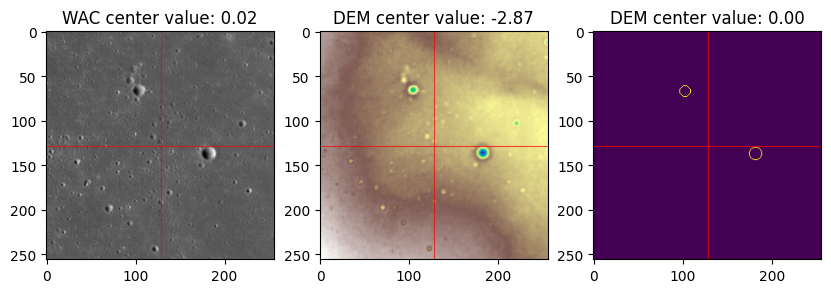

In [10]:
# checking the wac and dem aligh
patch_idx = 100

fig, axes = plt.subplots(1, 3, figsize=(10, 5))

axes[0].imshow(wac_check[patch_idx], cmap='gray')
axes[0].axhline(128, color='r', linewidth=0.8, alpha=0.7)
axes[0].axvline(128, color='r', linewidth=0.8, alpha=0.7)
axes[0].set_title(f"WAC center value: {wac_check[patch_idx][128, 128]:.2f}")

axes[1].imshow(dem_check[patch_idx], cmap='terrain')
axes[1].axhline(128, color='r', linewidth=0.8, alpha=0.7)
axes[1].axvline(128, color='r', linewidth=0.8, alpha=0.7)
axes[1].set_title(f"DEM center value: {dem_check[patch_idx][128, 128]:.2f}")

axes[2].imshow(mask_check[patch_idx])
axes[2].axhline(128, color='r', linewidth=0.8, alpha=0.7)
axes[2].axvline(128, color='r', linewidth=0.8, alpha=0.7)
axes[2].set_title(f"DEM center value: {mask_check[patch_idx][128, 128]:.2f}")


plt.show()


## Normalisation and loss choices

The normalisation:`LRO_data_class.getNormalisedBatch()` -> per-patch percentile, wac/dem

Patches analysis to justify:
- **why percentile normalisation** — raw WAC and DEM have very different, per-patch-variable ranges
- **why the loss must be weighted** — crater rim pixels are a tiny minority


In [11]:
sample_batch = 50
wac_raw  = np.load(os.path.join(PATCHES_DIR, f'X_wac_{sample_batch}.npz'))['arr_0']
dem_raw  = np.load(os.path.join(PATCHES_DIR, f'X_dem_{sample_batch}.npz'))['arr_0']
mask_raw = np.load(os.path.join(PATCHES_DIR, f'X_mask_{sample_batch}.npz'))['arr_0']


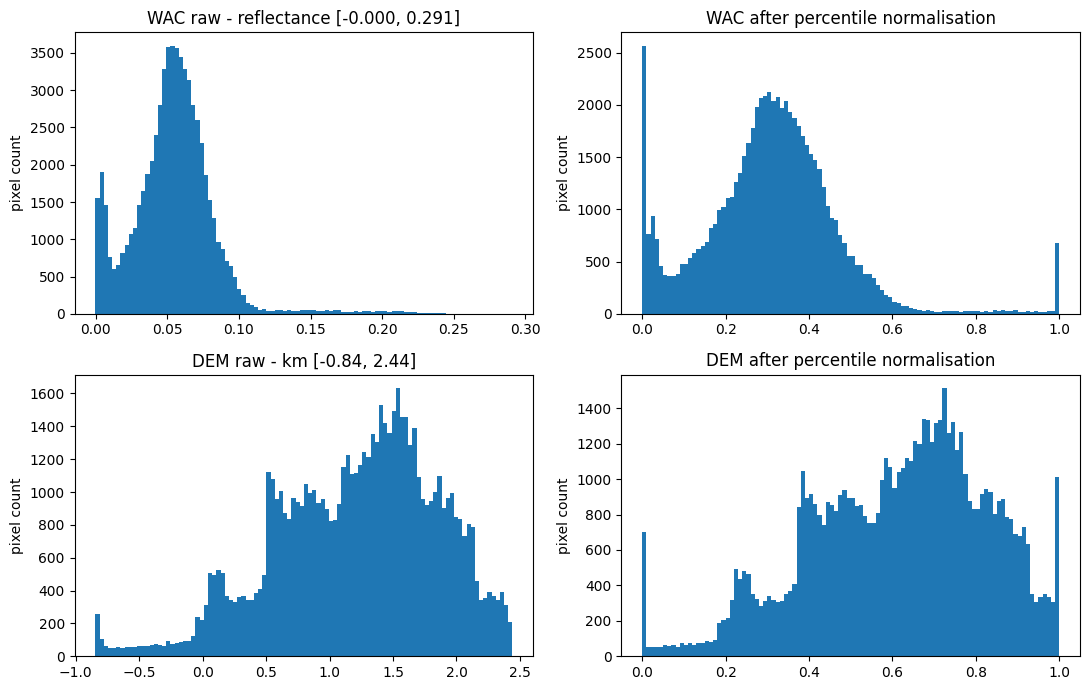

WAC raw range across batch: [-0.0026, 0.3169]
DEM raw range across batch: [-4.23, 2.45] km


In [12]:
fig, axes = plt.subplots(2, 2, figsize=(11, 7))
j = 0

# WAC - float32 reflectance, NOT 8-bit DN
axes[0, 0].hist(wac_raw[j].flatten(), bins=100)
axes[0, 0].set_title(f'WAC raw - reflectance [{wac_raw[j].min():.3f}, {wac_raw[j].max():.3f}]')
axes[0, 1].hist(percentileNormalise(wac_raw[j]).flatten(), bins=100)
axes[0, 1].set_title('WAC after percentile normalisation')

# DEM - elevation in km
axes[1, 0].hist(dem_raw[j].flatten(), bins=100)
axes[1, 0].set_title(f'DEM raw - km [{dem_raw[j].min():.2f}, {dem_raw[j].max():.2f}]')
axes[1, 1].hist(percentileNormalise(dem_raw[j]).flatten(), bins=100)
axes[1, 1].set_title('DEM after percentile normalisation')

for ax in axes.flat:
    ax.set_ylabel('pixel count')

plt.tight_layout()
plt.show()

# spikes at 0 and 1 -> clipped 1st/99th percentile tails
print('WAC raw range across batch: [%.4f, %.4f]' % (wac_raw.min(), wac_raw.max()))
print('DEM raw range across batch: [%.2f, %.2f] km' % (dem_raw.min(), dem_raw.max()))


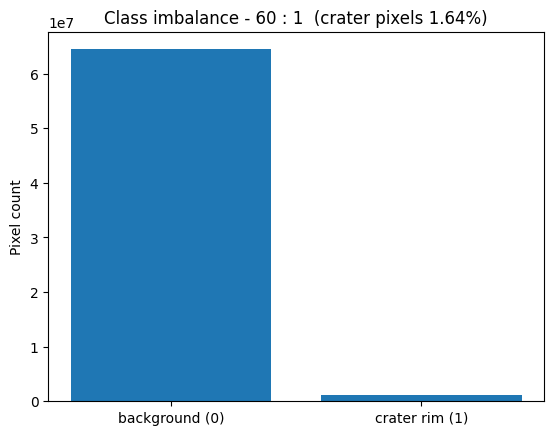

In [13]:
# Crater vs background pixels
acc0 = (mask_raw == 0).sum()
acc1 = (mask_raw == 1).sum()

ratio = acc0 / acc1
frac  = acc1 / (acc0 + acc1)

plt.bar(['background (0)', 'crater rim (1)'], [acc0, acc1])
plt.title(f'Class imbalance - {ratio:.0f} : 1  (crater pixels {frac*100:.2f}%)')
plt.ylabel('Pixel count')
plt.show()


In [14]:
# Region split by longitude
# Neighbouring patches overlap
# random split puts the same terrain in train AND test -> spatial leakage -> inflated test scores.
# Whole bands instead: train 0-252E / val 252-306E / test 306-360E

patch_lon = kept_labels['patch_lon'].values
patch_lat = kept_labels['patch_lat'].values

px_per_deg = dataWAC.shape[1] / lon_span
half_width = (128 / np.cos(np.radians(patch_lat))) / px_per_deg

train_idx = np.where(patch_lon + half_width < 252)[0]
val_idx   = np.where((patch_lon - half_width >= 252) & (patch_lon + half_width < 306))[0]
test_idx  = np.where(patch_lon - half_width >= 306)[0]

total = len(patch_lon)
dropped = total - len(train_idx) - len(val_idx) - len(test_idx)
print(f'Train: {len(train_idx)} patches ({len(train_idx)/total*100:.1f}%)')
print(f'Val:   {len(val_idx)} patches ({len(val_idx)/total*100:.1f}%)')
print(f'Test:  {len(test_idx)} patches ({len(test_idx)/total*100:.1f}%)')
print(f'Dropped at band boundaries: {dropped}  (half-width {half_width.min():.2f}-{half_width.max():.2f} deg)')

Train: 982147 patches (80.0%)
Val:   123649 patches (10.1%)
Test:  116033 patches (9.5%)
Dropped at band boundaries: 5142  (half-width 0.42-0.83 deg)


In [15]:
np.save(os.path.join(PATCHES_DIR, 'train_idx.npy'), train_idx)
np.save(os.path.join(PATCHES_DIR, 'val_idx.npy'), val_idx)
np.save(os.path.join(PATCHES_DIR, 'test_idx.npy'), test_idx)